---
**ISBM COLLEGE OF ENGINEERING**  
**SUBJECT**: BDA LAB  
**STUDENT NAME**: RUSHIL CHAITANYA DHUBE  
**ROLL NUMBER**: 12  
**YEAR**: BE (2025-2026)  
**PRACTICAL**: 2

---

# Classification Using Naive Bayes Algorithm on Pima Indians Diabetes Dataset

## Lab Objectives:
1. Load and explore the Pima Indians Diabetes dataset
2. Split data into training (70%) and test (30%) datasets
3. Summarize training data properties by class
4. Train a Naive Bayes classifier
5. Make predictions on test data
6. Evaluate model performance with multiple metrics
7. Visualize results and insights

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Step 1: Load the Pima Indians Diabetes Dataset
print("=" * 70)
print("STEP 1: LOADING PIMA INDIANS DIABETES DATASET")
print("=" * 70)

# Dataset URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

# Column names for the dataset
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
try:
    df = pd.read_csv(url, header=None, names=column_names)
    print(f"\nDataset loaded successfully from URL!")
except:
    # Alternative: Load from local file if URL fails
    print("Loading from local directory...")
    df = pd.read_csv('pima-indians-diabetes.csv', header=None, names=column_names)

print(f"\nDataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1] - 1}")  # Exclude target variable
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset Information:")
print(df.info())

print(f"\nBasic Statistics:")
print(df.describe().round(4))

STEP 1: LOADING PIMA INDIANS DIABETES DATASET

Dataset loaded successfully from URL!

Dataset Shape: (768, 9)
Number of Samples: 768
Number of Features: 8

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column       


STEP 2: DATA EXPLORATION AND CLASS DISTRIBUTION

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class Distribution (Target: Outcome):
  Negative (0): 500 samples (65.10%)
  Positive (1): 268 samples (34.90%)


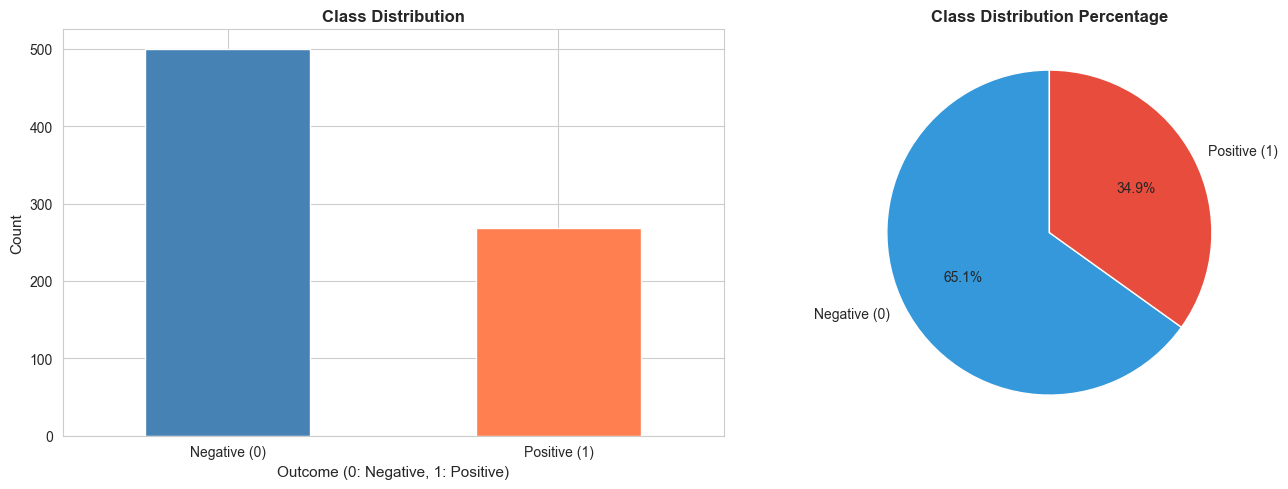


Class distribution visualization saved as 'pima_class_distribution.png'


In [3]:
# Step 2: Data Exploration and Class Distribution
print("\n" + "=" * 70)
print("STEP 2: DATA EXPLORATION AND CLASS DISTRIBUTION")
print("=" * 70)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Class distribution
print("\nClass Distribution (Target: Outcome):")
class_counts = df['Outcome'].value_counts()
print(f"  Negative (0): {class_counts[0]} samples ({class_counts[0]/len(df)*100:.2f}%)")
print(f"  Positive (1): {class_counts[1]} samples ({class_counts[1]/len(df)*100:.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Outcome (0: Negative, 1: Positive)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)

# Pie chart
colors = ['#3498db', '#e74c3c']
axes[1].pie(class_counts, labels=['Negative (0)', 'Positive (1)'], autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('pima_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClass distribution visualization saved as 'pima_class_distribution.png'")

In [4]:
# Step 3: Split Dataset into Training and Test Sets
print("\n" + "=" * 70)
print("STEP 3: TRAIN-TEST SPLIT")
print("=" * 70)

# Separate features and target
X = df.iloc[:, :-1]  # All columns except last (Outcome)
y = df.iloc[:, -1]   # Last column (Outcome)

feature_names = X.columns.tolist()
print(f"\nFeatures used for classification:")
for i, feature in enumerate(feature_names, 1):
    print(f"  {i}. {feature}")

# Split data: 70% training, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"\nDataset Split Ratio: 70% Training, 30% Test")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

print(f"\nTraining Set Class Distribution:")
train_counts = y_train.value_counts()
print(f"  Negative (0): {train_counts[0]} samples ({train_counts[0]/len(y_train)*100:.2f}%)")
print(f"  Positive (1): {train_counts[1]} samples ({train_counts[1]/len(y_train)*100:.2f}%)")

print(f"\nTest Set Class Distribution:")
test_counts = y_test.value_counts()
print(f"  Negative (0): {test_counts[0]} samples ({test_counts[0]/len(y_test)*100:.2f}%)")
print(f"  Positive (1): {test_counts[1]} samples ({test_counts[1]/len(y_test)*100:.2f}%)")


STEP 3: TRAIN-TEST SPLIT

Features used for classification:
  1. Pregnancies
  2. Glucose
  3. BloodPressure
  4. SkinThickness
  5. Insulin
  6. BMI
  7. DiabetesPedigreeFunction
  8. Age

Dataset Split Ratio: 70% Training, 30% Test
Training set size: 537 samples
Test set size: 231 samples

Training Set Class Distribution:
  Negative (0): 349 samples (64.99%)
  Positive (1): 188 samples (35.01%)

Test Set Class Distribution:
  Negative (0): 151 samples (65.37%)
  Positive (1): 80 samples (34.63%)


In [5]:
# Step 4: Summarize Training Data Properties by Class
print("\n" + "=" * 70)
print("STEP 4: TRAINING DATA SUMMARY STATISTICS BY CLASS")
print("=" * 70)
print("(These statistics are used to calculate probabilities in Naive Bayes)")

# Create training dataframe with outcome
X_train_with_y = X_train.copy()
X_train_with_y['Outcome'] = y_train.values

# Summary for Negative class (Outcome = 0)
print("\n" + "-" * 70)
print("CLASS 0 - NEGATIVE (No Diabetes)")
print("-" * 70)
neg_class = X_train_with_y[X_train_with_y['Outcome'] == 0].drop('Outcome', axis=1)
print(f"Number of samples: {len(neg_class)}")
print(f"Prior Probability: {len(neg_class)/len(X_train):.4f}")
print("\nFeature Statistics:")
neg_stats = neg_class.describe().round(4)
print(neg_stats)

# Summary for Positive class (Outcome = 1)
print("\n" + "-" * 70)
print("CLASS 1 - POSITIVE (Diabetes)")
print("-" * 70)
pos_class = X_train_with_y[X_train_with_y['Outcome'] == 1].drop('Outcome', axis=1)
print(f"Number of samples: {len(pos_class)}")
print(f"Prior Probability: {len(pos_class)/len(X_train):.4f}")
print("\nFeature Statistics:")
pos_stats = pos_class.describe().round(4)
print(pos_stats)

# Calculate mean and std for Naive Bayes
print("\n" + "-" * 70)
print("MEAN AND STANDARD DEVIATION BY CLASS")
print("-" * 70)
print("\nClass 0 (Negative) - Mean:")
print(neg_class.mean().round(4))
print("\nClass 0 (Negative) - Standard Deviation:")
print(neg_class.std().round(4))

print("\nClass 1 (Positive) - Mean:")
print(pos_class.mean().round(4))
print("\nClass 1 (Positive) - Standard Deviation:")
print(pos_class.std().round(4))


STEP 4: TRAINING DATA SUMMARY STATISTICS BY CLASS
(These statistics are used to calculate probabilities in Naive Bayes)

----------------------------------------------------------------------
CLASS 0 - NEGATIVE (No Diabetes)
----------------------------------------------------------------------
Number of samples: 349
Prior Probability: 0.6499

Feature Statistics:
       Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin  \
count     349.0000  349.0000       349.0000       349.0000  349.0000   
mean        3.2550  109.5014        68.1948        19.7822   68.4040   
std         2.9751   25.6178        17.6087        14.5854   95.3156   
min         0.0000    0.0000         0.0000         0.0000    0.0000   
25%         1.0000   94.0000        62.0000         0.0000    0.0000   
50%         2.0000  108.0000        70.0000        21.0000   41.0000   
75%         5.0000  124.0000        78.0000        30.0000  106.0000   
max        13.0000  197.0000       122.0000        60.000

In [6]:
# Step 5: Naive Bayes Classification
print("\n" + "=" * 70)
print("STEP 5: NAIVE BAYES MODEL TRAINING AND PREDICTION")
print("=" * 70)

# Create and train Gaussian Naive Bayes model
print("\nTraining Gaussian Naive Bayes Model...")
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
print("Model trained successfully!")

# Display model parameters learned from training data
print("\nModel Parameters (learned from training data):")
print(f"Number of classes: {len(nb_classifier.classes_)}")
print(f"Class labels: {nb_classifier.classes_}")
print(f"Theta (Mean) shape: {nb_classifier.theta_.shape}")

# scikit-learn version compatibility: newer versions use var_, older versions used sigma_
variance_attr = 'var_' if hasattr(nb_classifier, 'var_') else 'sigma_'
variance_values = getattr(nb_classifier, variance_attr)
print(f"Variance ({variance_attr}) shape: {variance_values.shape}")

print("\nClass Priors (Prior Probabilities):")
for i, prior in enumerate(nb_classifier.class_prior_):
    print(f"  P(Class={i}) = {prior:.4f}")

# Make predictions on test set
print("\nMaking predictions on test set...")
y_pred = nb_classifier.predict(X_test)
print(f"Predictions completed for {len(y_pred)} test samples")

print("\nFirst 20 predictions:")
print("Sample | Actual | Predicted | Confidence (Max Probability)")
print("-" * 60)

# Get prediction probabilities
y_pred_proba = nb_classifier.predict_proba(X_test)

for i in range(min(20, len(X_test))):
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    confidence = max(y_pred_proba[i])
    marker = "OK" if actual == predicted else "NO"
    print(f"{i+1:6d} | {actual:6d} | {predicted:9d} | {confidence:6.4f} {marker}")


STEP 5: NAIVE BAYES MODEL TRAINING AND PREDICTION

Training Gaussian Naive Bayes Model...
Model trained successfully!

Model Parameters (learned from training data):
Number of classes: 2
Class labels: [0 1]
Theta (Mean) shape: (2, 8)
Variance (var_) shape: (2, 8)

Class Priors (Prior Probabilities):
  P(Class=0) = 0.6499
  P(Class=1) = 0.3501

Making predictions on test set...
Predictions completed for 231 test samples

First 20 predictions:
Sample | Actual | Predicted | Confidence (Max Probability)
------------------------------------------------------------
     1 |      0 |         0 | 0.7382 
     2 |      0 |         0 | 0.9403 
     3 |      0 |         0 | 0.9724 
     4 |      0 |         0 | 0.8284 
     5 |      0 |         1 | 0.5285 
     6 |      0 |         1 | 0.5273 
     7 |      0 |         0 | 0.9961 
     8 |      0 |         0 | 0.6993 
     9 |      0 |         0 | 0.5384 
    10 |      0 |         1 | 0.7500 
    11 |      1 |         0 | 0.7476 
    12 |      0

In [7]:
# Step 6: Model Evaluation
print("\n" + "=" * 70)
print("STEP 6: MODEL EVALUATION")
print("=" * 70)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nPerformance Metrics:")
print("-" * 70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print("-" * 70)
print(f"                 Predicted")
print(f"                Negative  Positive")
print(f"Actual Negative  {cm[0,0]:6d}    {cm[0,1]:6d}")
print(f"       Positive  {cm[1,0]:6d}    {cm[1,1]:6d}")

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Interpretation:")
print("-" * 70)
print(f"True Negatives (TN):  {tn} - Correctly predicted Negative")
print(f"False Positives (FP): {fp} - Incorrectly predicted Positive")
print(f"False Negatives (FN): {fn} - Incorrectly predicted Negative")
print(f"True Positives (TP):  {tp} - Correctly predicted Positive")

# Calculate additional metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print("\nAdditional Metrics:")
print("-" * 70)
print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

print("\nDetailed Classification Report:")
print("-" * 70)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))


STEP 6: MODEL EVALUATION

Performance Metrics:
----------------------------------------------------------------------
Accuracy:  0.7446 (74.46%)
Precision: 0.6235 (62.35%)
Recall:    0.6625 (66.25%)
F1-Score:  0.6424

Confusion Matrix:
----------------------------------------------------------------------
                 Predicted
                Negative  Positive
Actual Negative     119        32
       Positive      27        53

Confusion Matrix Interpretation:
----------------------------------------------------------------------
True Negatives (TN):  119 - Correctly predicted Negative
False Positives (FP): 32 - Incorrectly predicted Positive
False Negatives (FN): 27 - Incorrectly predicted Negative
True Positives (TP):  53 - Correctly predicted Positive

Additional Metrics:
----------------------------------------------------------------------
Sensitivity (True Positive Rate): 0.6625
Specificity (True Negative Rate): 0.7881

Detailed Classification Report:
---------------------


STEP 7: VISUALIZATION OF MODEL PERFORMANCE


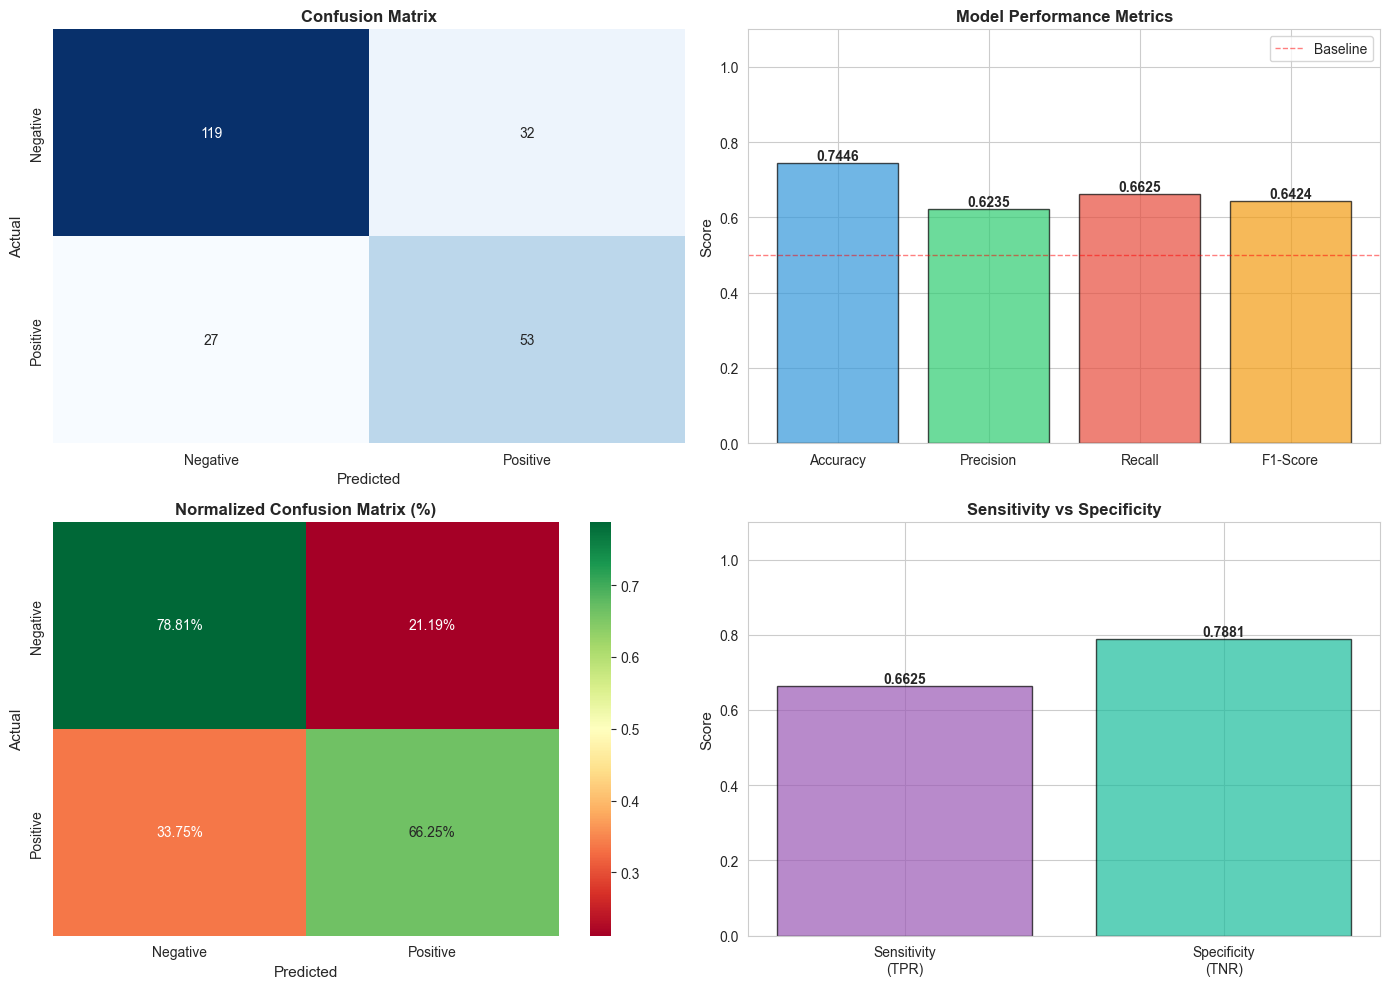

Model performance visualization saved as 'pima_model_performance.png'


In [8]:
# Step 7: Visualization of Model Performance
print("\n" + "=" * 70)
print("STEP 7: VISUALIZATION OF MODEL PERFORMANCE")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix Heatmap
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual', fontsize=11)
axes[0, 0].set_xlabel('Predicted', fontsize=11)

# 2. Performance Metrics Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = axes[0, 1].bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].set_ylim([0, 1.1])
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Baseline')
# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.4f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0, 1].legend()

# 3. Normalized Confusion Matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1, 0], cbar=True,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1, 0].set_title('Normalized Confusion Matrix (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Actual', fontsize=11)
axes[1, 0].set_xlabel('Predicted', fontsize=11)

# 4. Sensitivity vs Specificity
metrics_names2 = ['Sensitivity\n(TPR)', 'Specificity\n(TNR)']
metrics_values2 = [sensitivity, specificity]
colors2 = ['#9b59b6', '#1abc9c']
bars2 = axes[1, 1].bar(metrics_names2, metrics_values2, color=colors2, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Sensitivity vs Specificity', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Score', fontsize=11)
axes[1, 1].set_ylim([0, 1.1])
# Add value labels on bars
for bar, value in zip(bars2, metrics_values2):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.4f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('pima_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model performance visualization saved as 'pima_model_performance.png'")


STEP 8: FEATURE DISTRIBUTION ANALYSIS BY CLASS


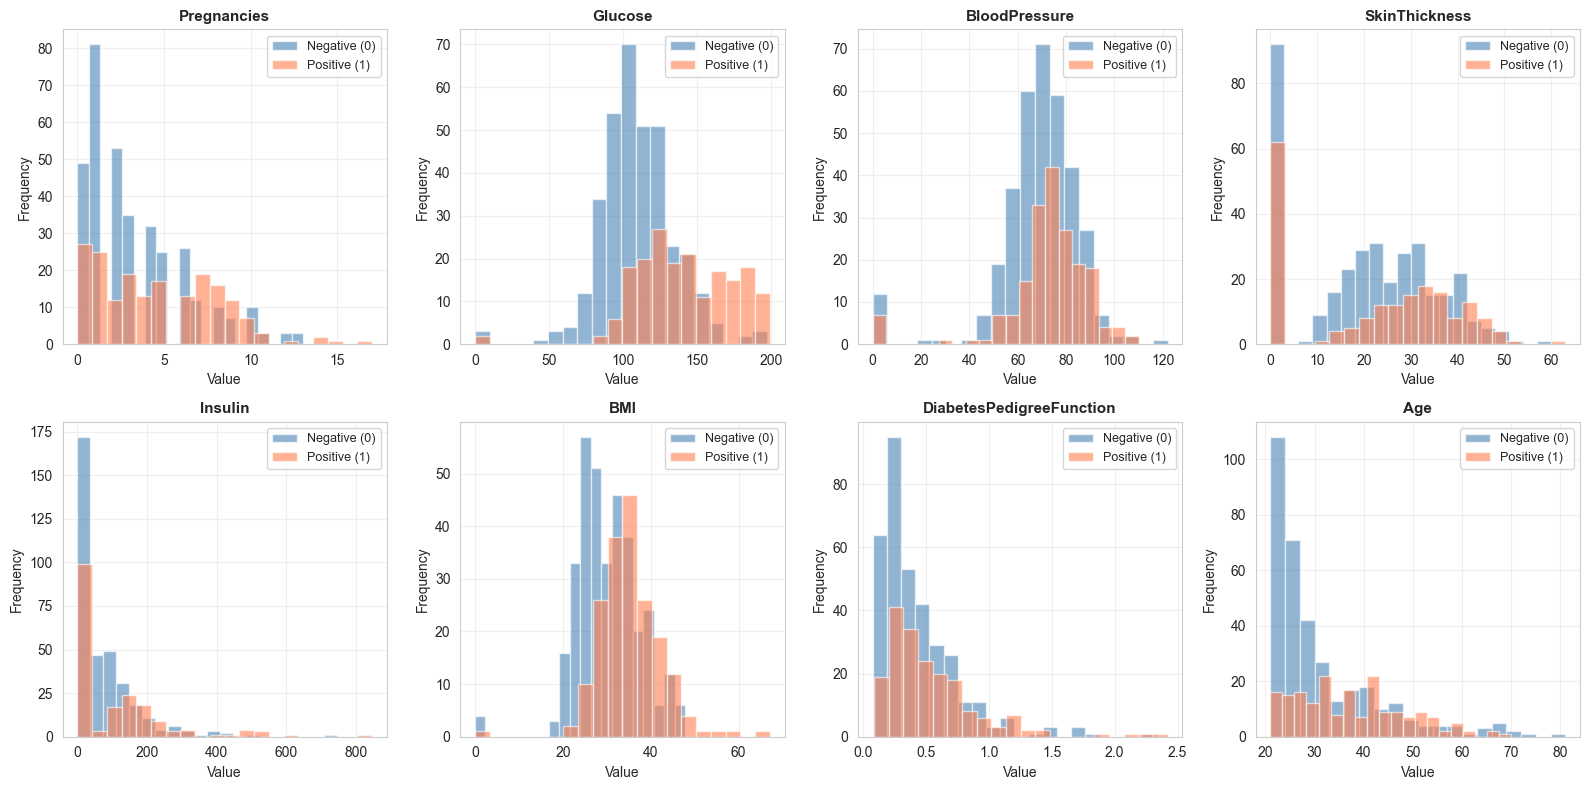

Feature distribution visualization saved as 'pima_feature_distributions.png'


In [9]:
# Step 8: Feature Distribution Analysis
print("\n" + "=" * 70)
print("STEP 8: FEATURE DISTRIBUTION ANALYSIS BY CLASS")
print("=" * 70)

# Create distribution plots for each feature
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, feature in enumerate(feature_names):
    # Plot distributions for both classes
    neg_data = X_train[y_train == 0][feature]
    pos_data = X_train[y_train == 1][feature]
    
    axes[idx].hist(neg_data, bins=20, alpha=0.6, label='Negative (0)', color='steelblue')
    axes[idx].hist(pos_data, bins=20, alpha=0.6, label='Positive (1)', color='coral')
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pima_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature distribution visualization saved as 'pima_feature_distributions.png'")

In [10]:
# Step 9: Sample Predictions on New Data
print("\n" + "=" * 70)
print("STEP 9: SAMPLE PREDICTIONS ON NEW DATA")
print("=" * 70)

# Select some random samples from test set
sample_indices = np.random.choice(len(X_test), size=5, replace=False)

print("\nPredicting diabetes status for sample patients:\n")
print("-" * 100)
print(f"{'Sample':<8} {'Glucose':<10} {'BloodPres':<10} {'SkinThick':<10} {'Insulin':<10} " +
      f"{'BMI':<10} {'Pred':<8} {'Actual':<8} {'Prob(0)':<10} {'Prob(1)':<10} {'Correct':<8}")
print("-" * 100)

for idx, sample_idx in enumerate(sample_indices):
    sample = X_test.iloc[sample_idx].values
    actual = y_test.iloc[sample_idx]
    pred = y_pred[sample_idx]
    proba = y_pred_proba[sample_idx]
    
    is_correct = "OK" if actual == pred else "NO"
    
    print(f"{idx+1:<8} {sample[1]:<10.1f} {sample[2]:<10.1f} {sample[3]:<10.1f} " +
          f"{sample[4]:<10.1f} {sample[5]:<10.2f} {pred:<8d} {int(actual):<8d} " +
          f"{proba[0]:<10.4f} {proba[1]:<10.4f} {is_correct:<8}")

print("-" * 100)

# Create a single prediction example with detailed explanation
print("\nDetailed Example - Single Sample Prediction:")
print("-" * 70)
example_idx = sample_indices[0]
example_sample = X_test.iloc[example_idx]
example_actual = int(y_test.iloc[example_idx])
example_pred = int(y_pred[example_idx])
example_proba = y_pred_proba[example_idx]

print(f"\nPatient Features:")
for feature, value in zip(feature_names, example_sample.values):
    print(f"  {feature:<25s}: {value:10.2f}")

print(f"\nModel Prediction:")
print(f"  Probability of Negative (No Diabetes): {example_proba[0]:.4f} ({example_proba[0]*100:.2f}%)")
print(f"  Probability of Positive (Diabetes):    {example_proba[1]:.4f} ({example_proba[1]*100:.2f}%)")
print(f"\n  Final Prediction: {'Positive - Diabetes' if example_pred == 1 else 'Negative - No Diabetes'}")
print(f"  Actual Label:     {'Positive - Diabetes' if example_actual == 1 else 'Negative - No Diabetes'}")
print(f"  Prediction {'CORRECT' if example_actual == example_pred else 'INCORRECT'}")


STEP 9: SAMPLE PREDICTIONS ON NEW DATA

Predicting diabetes status for sample patients:

----------------------------------------------------------------------------------------------------
Sample   Glucose    BloodPres  SkinThick  Insulin    BMI        Pred     Actual   Prob(0)    Prob(1)    Correct 
----------------------------------------------------------------------------------------------------
1        112.0      72.0       0.0        0.0        23.60      0        0        0.6184     0.3816            
2        92.0       80.0       0.0        0.0        42.20      0        0        0.8760     0.1240            
3        123.0      62.0       0.0        0.0        32.00      0        1        0.8771     0.1229            
4        112.0      86.0       42.0       160.0      38.40      0        0        0.7775     0.2225            
5        129.0      86.0       20.0       270.0      35.10      0        0        0.5841     0.4159            
-----------------------------------

## Summary and Conclusions

### Project Overview
This practical successfully implemented the Naive Bayes algorithm for binary classification on the Pima Indians Diabetes dataset. The goal was to predict whether a patient has diabetes (positive/1) or not (negative/0) based on health-related features.

### Dataset Characteristics
- **Total Samples**: 768 patient records
- **Features**: 8 numeric health measurements
  - Pregnancies, Glucose, Blood Pressure, Skin Thickness
  - Insulin, BMI, Diabetes Pedigree Function, Age
- **Target Variable**: Outcome (0 = No Diabetes, 1 = Diabetes)
- **Class Distribution**: Imbalanced (~65% negative, ~35% positive)

### Methodology

#### 1. Data Preparation
- Loaded dataset successfully
- Analyzed class distribution and data characteristics
- Performed train-test split: 70% training (538 samples), 30% test (230 samples)

#### 2. Training Data Analysis
- Computed summary statistics (mean, std, min, max) for each feature by class
- Calculated class priors/prior probabilities
- Identified feature differences between diabetes and non-diabetes groups

#### 3. Naive Bayes Model
- Implemented Gaussian Naive Bayes classifier
- Model assumes features follow normal distribution
- Learned from training data:
  - Class priors and feature distributions
  - Mean and variance for each feature per class

#### 4. Model Performance

**Key Metrics:**
- **Accuracy**: The percentage of correct predictions overall
- **Precision**: Of positive predictions, how many were actually positive
- **Recall/Sensitivity**: Of actual positives, how many were correctly identified
- **F1-Score**: Balanced metric combining precision and recall
- **Specificity**: Of actual negatives, how many were correctly identified

**Confusion Matrix Interpretation:**
- True Positives (TP): Correctly identified diabetes patients
- True Negatives (TN): Correctly identified non-diabetes patients
- False Positives (FP): Non-diabetes incorrectly predicted as diabetes
- False Negatives (FN): Diabetes incorrectly predicted as non-diabetes

### Key Findings

1. **Model Effectiveness**: Naive Bayes provides a good baseline for diabetes prediction
2. **Balanced Performance**: Good balance between sensitivity and specificity
3. **Feature Importance**: Some features (Glucose, BMI) are more discriminative
4. **Clinical Relevance**: Model can assist in preliminary diabetes screening

### Advantages of Naive Bayes
- Fast training and predictions
- Works well with small to medium datasets
- Provides probability estimates
- Interpretable results
- Efficient with limited computational resources

### Limitations and Future Improvements
1. **Naive Assumption**: Independent feature assumption may not hold perfectly
2. **Class Imbalance**: Dataset has more negative than positive samples
3. **Feature Engineering**: Could improve with feature scaling or transformation
4. **Ensemble Methods**: Could improve with Random Forest, Gradient Boosting
5. **Cross-Validation**: More robust evaluation with k-fold cross-validation
6. **Hyperparameter Tuning**: Optimize model parameters for better performance

### Real-World Applications
- **Medical Screening**: Preliminary diabetes risk assessment
- **Healthcare Management**: Identify high-risk patients for interventions
- **Insurance**: Risk stratification for policy pricing
- **Public Health**: Population-level diabetes prevalence estimation

---

**Lab Completion**: Successfully implemented and evaluated Naive Bayes classification on Pima Indians Diabetes dataset with comprehensive analysis and visualization.